In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Deep-Learning/dataset_ready.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15585 entries, 0 to 15584
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sofascore_slug     15585 non-null  object 
 1   transfermarkt_url  15585 non-null  object 
 2   player_name        15585 non-null  object 
 3   nationality        15349 non-null  object 
 4   foot               15269 non-null  object 
 5   season             15585 non-null  object 
 6   league             15585 non-null  object 
 7   position_label     15585 non-null  object 
 8   heatmap_filename   15585 non-null  object 
 9   General_MP         15585 non-null  float64
 10  General_MIN        15585 non-null  int64  
 11  General_GLS        15585 non-null  float64
 12  General_AST        15585 non-null  int64  
 13  General_ASR        15532 non-null  float64
 14  Shooting_MP        15576 non-null  float64
 15  Shooting_GLS       15576 non-null  float64
 16  Shooting_TOS       154

In [ ]:
data_clean = df.dropna(subset = ['heatmap_filename']).copy()
print(f"Toplam Veri Sayısı: {len(df)}")
print(f"\nIsı Haritası Olanların Sayısı: {len(data_clean)}")
print(f"\nIsı Haritası Olmayanların Sayısı: {(len(df) - len(data_clean))}")

Toplam Veri Sayısı: 15585

Isı Haritası Olanların Sayısı: 15585

Isı Haritası Olmayanların Sayısı: 0


---- Mevki Dağılımı ----

position_label
Centre-Back           4326
Centre-Forward        2005
Central Midfield      1766
Defensive Midfield    1728
Right-Back            1276
Left-Back             1245
Attacking Midfield     783
Right Winger           773
Left Winger            699
Right Midfield         461
Left Midfield          424
Second Striker          99
Name: count, dtype: int64


/tmp/ipython-input-1596336847.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


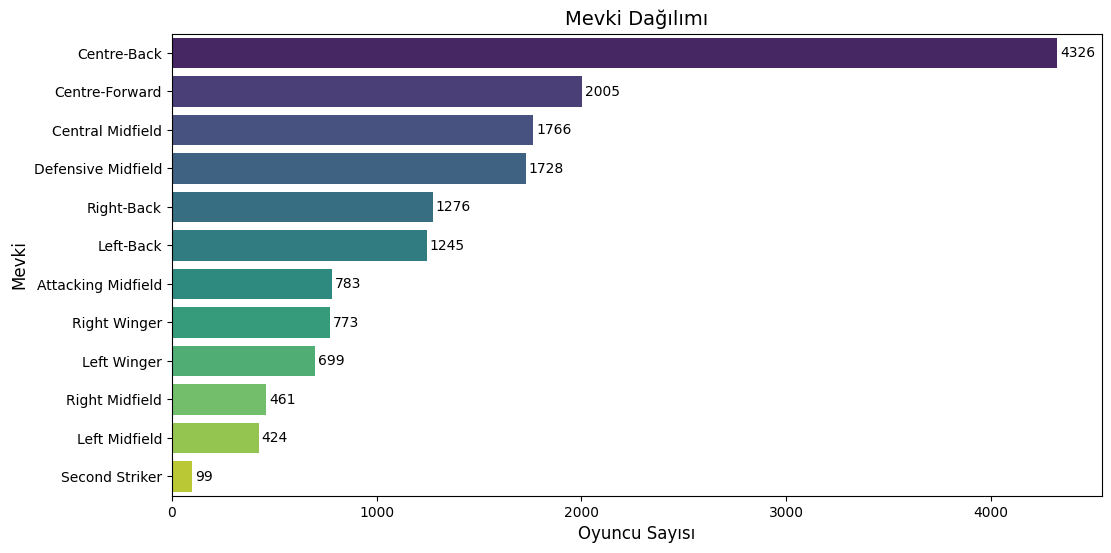

In [ ]:
print("---- Mevki Dağılımı ----")
print(f"\n{data_clean['position_label'].value_counts()}")

plt.figure(figsize = (12, 6))

ax = sns.countplot(
    data = data_clean,
    y = 'position_label',
    order = data_clean['position_label'].value_counts().index,
    palette = 'viridis'
)

plt.title('Mevki Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Sayısı', fontsize=12)
plt.ylabel('Mevki', fontsize=12)

for container in ax.containers:
  ax.bar_label(container, padding = 2)
plt.show()


Toplam Eksik Veri Sayısı: 
Additional_xGI    11369
Additional_xG     11332
Additional_xA     11328
Passing_CA%        2977
Defending_BLS      1197
Passing_ACR         792
Shooting_SOT        104
Shooting_TOS         99
Defending_ADW        78
Passing_LBA%         60
General_ASR          53
Passing_ALB          22
Defending_ELTG       10
Shooting_GLS          9
Shooting_MP           9
Additional_GI         8
Team play_SDR         7
Shooting_BCM          7
Team play_MP          7
Team play_AST         7
Team play_KEYP        7
Team play_BCC         7
Additional_AST        7
Defending_DRP         2
Defending_MP          2
Passing_APS%          1
Passing_MP            1
Passing_APS           1
Defending_INT         1
Defending_YC          1
Defending_RC          1
Defending_CLS         1
Defending_TACK        1
Additional_GLS        1
Additional_MP         1
dtype: int64


/tmp/ipython-input-3278792025.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = missing_data.index, y=missing_data.values, palette = 'Blues_r')


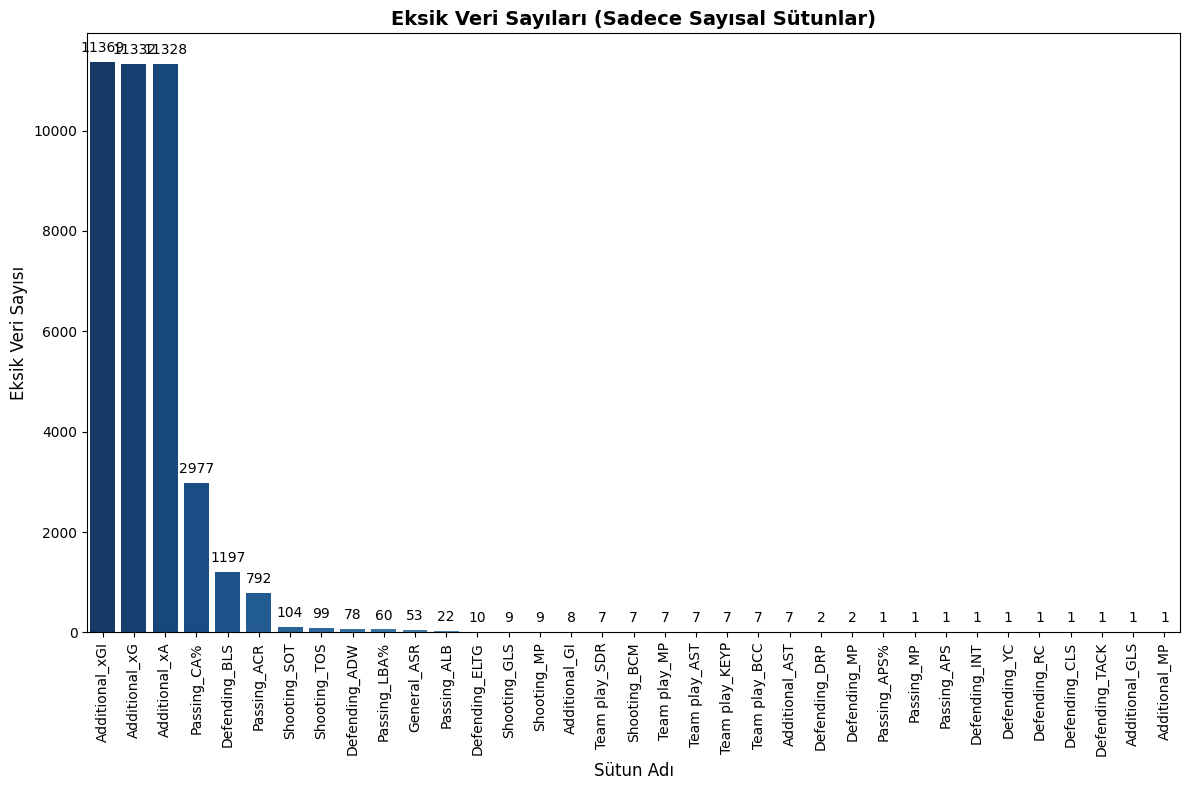

In [ ]:
numeric_cols = data_clean.select_dtypes(include=["float64", "int64"]).columns
missing_data = data_clean[numeric_cols].isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print(f"Toplam Eksik Veri Sayısı: \n{missing_data}")

plt.figure(figsize=(12, 8))

ax = sns.barplot(x = missing_data.index, y=missing_data.values, palette = 'Blues_r')

plt.title('Eksik Veri Sayıları (Sadece Sayısal Sütunlar)', fontsize=14, fontweight='bold')
plt.xlabel('Sütun Adı', fontsize=12)
plt.ylabel('Eksik Veri Sayısı', fontsize=12)
plt.xticks(rotation=90)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


Yeni Mevki Dağılımı

position_label
Centre-Back           4326
Centre-Forward        2104
Central Midfield      1766
Defensive Midfield    1728
Right-Back            1276
Left-Back             1245
Right Winger          1234
Left Winger           1123
Attacking Midfield     783
Name: count, dtype: int64


/tmp/ipython-input-3766543343.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  az = sns.countplot(


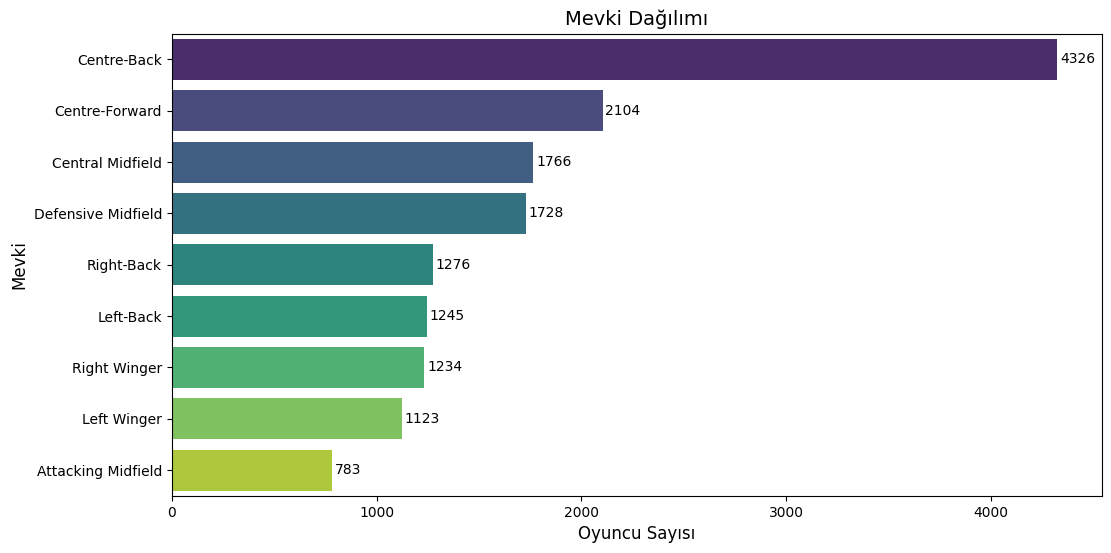

In [ ]:
data_refined = data_clean.copy()
replacements = {
    'Second Striker' : 'Centre-Forward',
    'Left Midfield' : 'Left Winger',
    'Right Midfield' : 'Right Winger'
    }
data_refined['position_label'] = data_refined['position_label'].replace(replacements)
print(f"\nYeni Mevki Dağılımı")
print(f"\n{data_refined['position_label'].value_counts()}")

plt.figure(figsize = (12, 6))
az = sns.countplot(
    data = data_refined,
    y = 'position_label',
    order = data_refined['position_label'].value_counts().index,
    palette = 'viridis'
)

plt.title('Mevki Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Sayısı', fontsize=12)
plt.ylabel('Mevki', fontsize=12)

for container in az.containers:
  az.bar_label(container, padding = 2)
plt.show()


In [ ]:
label_encoder = LabelEncoder()
data_refined['position_encoded'] = label_encoder.fit_transform(data_refined['position_label'])

print(f"\n--- Mevki - Sayı Eşleşmesi ---")
for i, label in enumerate(label_encoder.classes_):
  print(f"{i} - {label}")


--- Mevki - Sayı Eşleşmesi ---
0 - Attacking Midfield
1 - Central Midfield
2 - Centre-Back
3 - Centre-Forward
4 - Defensive Midfield
5 - Left Winger
6 - Left-Back
7 - Right Winger
8 - Right-Back


In [ ]:
cols_to_drop = ['Additional_xGI', 'Additional_xG', 'Additional_xA']

existing_cols_to_drop = [c for c in cols_to_drop if c in data_refined.columns]
data_refined = data_refined.drop(columns=existing_cols_to_drop)

print(f"Silinen Sütunlar: {existing_cols_to_drop}")

Silinen Sütunlar: ['Additional_xGI', 'Additional_xG', 'Additional_xA']


In [ ]:
numeric_cols = data_refined.select_dtypes(include=['float64', 'int64']).columns
data_refined[numeric_cols] = data_refined[numeric_cols].fillna(0)

In [ ]:
data_refined_v2 = data_refined.copy()
redundant_cols = ['Shooting_MP', 'Shooting_GLS',
    'Team play_MP', 'Team play_AST',
    'Passing_MP',
    'Defending_MP',
    'Additional_MP', 'Additional_GLS', 'Additional_AST']
data_refined_v2 = data_refined_v2.drop(columns=redundant_cols)
print(f"\nSilinen Sütunlar: {redundant_cols}")
print(f"\nKalan Sütun Sayısı: {len(data_refined_v2.columns)}")


Silinen Sütunlar: ['Shooting_MP', 'Shooting_GLS', 'Team play_MP', 'Team play_AST', 'Passing_MP', 'Defending_MP', 'Additional_MP', 'Additional_GLS', 'Additional_AST']

Kalan Sütun Sayısı: 37


In [ ]:
data_refined_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15585 entries, 0 to 15584
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sofascore_slug     15585 non-null  object 
 1   transfermarkt_url  15585 non-null  object 
 2   player_name        15585 non-null  object 
 3   nationality        15349 non-null  object 
 4   foot               15269 non-null  object 
 5   season             15585 non-null  object 
 6   league             15585 non-null  object 
 7   position_label     15585 non-null  object 
 8   heatmap_filename   15585 non-null  object 
 9   General_MP         15585 non-null  float64
 10  General_MIN        15585 non-null  int64  
 11  General_GLS        15585 non-null  float64
 12  General_AST        15585 non-null  int64  
 13  General_ASR        15585 non-null  float64
 14  Shooting_TOS       15585 non-null  float64
 15  Shooting_SOT       15585 non-null  float64
 16  Shooting_BCM       155

In [ ]:
print(data_refined.isnull().sum())
missing_data = data_refined.isnull().sum()
print(f"\n{missing_data[missing_data > 0].sort_values(ascending = False)}")

sofascore_slug         0
transfermarkt_url      0
player_name            0
nationality          236
foot                 316
season                 0
league                 0
position_label         0
heatmap_filename       0
General_MP             0
General_MIN            0
General_GLS            0
General_AST            0
General_ASR            0
Shooting_MP            0
Shooting_GLS           0
Shooting_TOS           0
Shooting_SOT           0
Shooting_BCM           0
Team play_MP           0
Team play_AST          0
Team play_KEYP         0
Team play_BCC          0
Team play_SDR          0
Passing_MP             0
Passing_APS            0
Passing_APS%           0
Passing_ALB            0
Passing_LBA%           0
Passing_ACR            0
Passing_CA%            0
Defending_MP           0
Defending_CLS          0
Defending_YC           0
Defending_RC           0
Defending_ELTG         0
Defending_DRP          0
Defending_TACK         0
Defending_INT          0
Defending_BLS          0


In [ ]:
file_path = '/content/drive/MyDrive/Deep-Learning/dataset_ready.csv'
data_refined_v2.to_csv(file_path, index = False)
print(f"Dosya Şuraya Kaydedildi: {file_path}")

Dosya Şuraya Kaydedildi: /content/drive/MyDrive/Deep-Learning/dataset_ready.csv


In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm


IMAGE_FOLDER_PATH = '/content/drive/MyDrive/Deep-Learning/heatmaps/'
SAVE_PATH = "/content/drive/MyDrive/Deep-Learning"
os.makedirs(SAVE_PATH, exist_ok=True)


df = pd.read_csv('/content/drive/MyDrive/Deep-Learning/dataset_ready.csv')
print(f"Toplam Veri Sayısı: {len(df)}")

print("🏷️ Etiketler kaydediliyor...")


y_labels = df['position_encoded'].values
np.save(os.path.join(SAVE_PATH, 'y_labels.npy'), y_labels)


le = LabelEncoder()
le.fit(df['position_label'])
joblib.dump(le, os.path.join(SAVE_PATH, 'position_encoder.pkl'))

print(f"✅ Etiketler .npy formatında kaydedildi. Sınıflar: {le.classes_}")


print("\n📊 İstatistikler (Stats) hazırlanıyor...")


drop_cols = ['position_label', 'position_encoded', 'heatmap_filename',
             'sofascore_slug', 'transfermarkt_url', 'player_name',
             'season', 'league', 'nationality', 'foot']

cols_to_drop = [c for c in drop_cols if c in df.columns]
X_stats_raw = df.drop(columns=cols_to_drop)
X_stats_raw = X_stats_raw.fillna(0)


scaler = StandardScaler()
X_stats = scaler.fit_transform(X_stats_raw)


np.save(os.path.join(SAVE_PATH, 'X_stats.npy'), X_stats)
print(f"✅ İstatistikler kaydedildi. Boyut: {X_stats.shape}")


print("\n🖼️ Resimler .npy formatına çevriliyor...")

IMG_SIZE = 128
X_images = []


for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    img_name = row['heatmap_filename']
    full_path = os.path.join(IMAGE_FOLDER_PATH, img_name)

    img = cv2.imread(full_path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X_images.append(img)
    else:
        X_images.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))


X_images = np.array(X_images, dtype=np.uint8)
np.save(os.path.join(SAVE_PATH, 'X_images_uint8.npy'), X_images)

print(f"✅ Resimler kaydedildi. Boyut: {X_images.shape}")

Toplam Veri Sayısı: 15585
🏷️ Etiketler kaydediliyor...
✅ Etiketler .npy formatında kaydedildi. Sınıflar: ['Attacking Midfield' 'Central Midfield' 'Centre-Back' 'Centre-Forward'
 'Defensive Midfield' 'Left Winger' 'Left-Back' 'Right Winger'
 'Right-Back']

📊 İstatistikler (Stats) hazırlanıyor...
✅ İstatistikler kaydedildi. Boyut: (15585, 27)

🖼️ Resimler .npy formatına çevriliyor...


100%|██████████| 15585/15585 [1:37:50<00:00,  2.65it/s]


✅ Resimler kaydedildi. Boyut: (15585, 128, 128, 3)
